<a href="https://colab.research.google.com/github/AlekAbrams/ann_traffic_final_project/blob/main/ANN_Stretch_LSTM_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import RMSprop

In [ ]:
# Load data
df = pd.read_csv("Traffic_Volume_Counts_20251111.csv")

# Fix date format (NYC is usually month/day/year)
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y", errors="coerce")

# Identify hourly columns
hourly_cols = [col for col in df.columns if ":" in col]
print("Hour columns found:", len(hourly_cols))

# Melt hourly cols
df_long = df.melt(
    id_vars=["ID", "SegmentID", "Roadway Name", "From", "To", "Direction", "Date"],
    value_vars=hourly_cols,
    var_name="Hour",
    value_name="Traffic_Count"
)

# Fix strings in traffic counts
df_long["Traffic_Count"] = (
    df_long["Traffic_Count"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# hour parser
def extract_start_time(hour_string):
    try:
        start = hour_string.split("-")[0].strip()      # "12:00"
        end = hour_string.split("-")[1].strip()        # "1:00 AM"

        # If start doesn't include AM/PM, borrow from the ending
        if "AM" not in start and "PM" not in start:
            suffix = end[-2:]                         # "AM" or "PM"
            start = f"{start} {suffix}"               # "12:00 AM"

        # Convert to datetime time
        return pd.to_datetime(start, format="%I:%M %p")
    except:
        return pd.NaT

df_long["Start_Time"] = df_long["Hour"].apply(extract_start_time)

# Drop invalid rows
df_long = df_long.dropna(subset=["Date", "Start_Time"])

# Extract hours and minutes from Start_Time
df_long["Start_Hour"] = df_long["Start_Time"].dt.hour
df_long["Start_Minute"] = df_long["Start_Time"].dt.minute

# Build full Datetime
df_long["Datetime"] = (
    df_long["Date"].dt.normalize()
    + pd.to_timedelta(df_long["Start_Hour"], unit="h")
    + pd.to_timedelta(df_long["Start_Minute"], unit="m")
)

# Sort final long table
df_long = df_long.sort_values(by=["SegmentID", "Datetime"]).reset_index(drop=True)


# ============================================
# SPLIT BY DATE (not by street)
# ============================================

# Get unique dates
unique_dates = sorted(df_long["Date"].unique())

# Shuffle dates and split 80/20
np.random.seed(42)
shuffled_dates = unique_dates.copy()
np.random.shuffle(shuffled_dates)

split_idx = int(len(shuffled_dates) * 0.8)
train_dates = set(shuffled_dates[:split_idx])
test_dates = set(shuffled_dates[split_idx:])

print(f"Training dates: {len(train_dates)}")
print(f"Testing dates: {len(test_dates)}")
print(f"Total dates: {len(unique_dates)}")

# Prepare wide (Datetime x SegmentID) table
df_wide = df_long.groupby(['Datetime','SegmentID'])['Traffic_Count'].sum().reset_index()
df_pivot = df_wide.pivot(index='Datetime', columns='SegmentID', values='Traffic_Count')

# Impute missing values
df_pivot = df_pivot.sort_index()
df_pivot = df_pivot.fillna(method='ffill').fillna(method='bfill')
df_pivot = df_pivot.fillna(0)

print('After imputation: rows (hours)=', df_pivot.shape[0], 'segments=', df_pivot.shape[1])


min_std_threshold = 10  # minimum standard deviation in cars

# Calculate std for each segment
segment_stds = df_pivot.std()

# Keep only segments with sufficient variance
valid_segments = segment_stds[segment_stds > min_std_threshold].index
df_pivot = df_pivot[valid_segments]

print(f"\n{'='*50}")
print(f"SEGMENT FILTERING")
print(f"{'='*50}")
print(f"Original segments: {len(segment_stds)}")
print(f"After filtering (std > {min_std_threshold}): {len(valid_segments)}")
print(f"Removed: {len(segment_stds) - len(valid_segments)} low-variance segments")
print(f"{'='*50}\n")

# Build sliding-window sequences: previous 24 hours -> next hour (for all segments jointly)
window = 24
values = df_pivot.values  # shape (T, n_segments)
T, n_segments = values.shape

X_list = []
y_list = []
datetimes_list = []

for i in range(window, T-1):
    X_list.append(values[i-window:i, :])        # (24, n_segments)
    y_list.append(values[i+1, :])               # next hour for every segment
    datetimes_list.append(df_pivot.index[i+1])  # store datetime for split

X = np.stack(X_list).astype(np.float32)  # (samples, 24, n_segments)
y = np.stack(y_list).astype(np.float32)  # (samples, n_segments)
datetimes = pd.Series(datetimes_list)

print('Dataset shapes -> X:', X.shape, 'y:', y.shape)



# Split by date: if the target datetime's date is in train_dates, it goes to train
train_mask = datetimes.dt.date.isin([d.date() for d in train_dates])
test_mask = datetimes.dt.date.isin([d.date() for d in test_dates])

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Scale features per-segment. Fit scalers on training data only.
scaler_X = StandardScaler()
X_train_2d = X_train.reshape(-1, n_segments)
X_test_2d = X_test.reshape(-1, n_segments)
X_train_scaled = scaler_X.fit_transform(X_train_2d).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test_2d).reshape(X_test.shape)

# For y (targets): scale per-segment using a separate scaler
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Build a joint LSTM model: input (24, n_segments) -> LSTM -> Dense(n_segments)
tf.random.set_seed(42)
model = Sequential([
    LSTM(128, activation='tanh', input_shape=(window, n_segments)),
    Dropout(0.2),
    Dense(n_segments)  # predict next-hour count for each segment
])

model.compile(
    loss='mse',
    optimizer=RMSprop(learning_rate=0.001),
    metrics=['mae']
)

model.summary()

# Train
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=2
)

# Evaluate on test set
eval_results = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print('Test (scaled) loss (MSE) and MAE:', eval_results)

y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print('Test MSE (original scale):', mse)
print('Test MAE (original scale):', mae)

# Example: show predictions for the first test sample (per-segment) vs truth
sample_idx = 0
pred_series = pd.Series(y_pred[sample_idx, :], index=df_pivot.columns)
true_series = pd.Series(y_test[sample_idx, :], index=df_pivot.columns)
print('Example per-street prediction (first test sample):')
print(pd.DataFrame({'pred': pred_series, 'true': true_series}).head(10))

Hour columns found: 24

DATE FILTERING AND SPLITTING
Using post-COVID data: 2020-10-03 00:00:00 to 2021-05-09 00:00:00
Total dates: 64

Training period: 2020-10-03 00:00:00 to 2020-12-09 00:00:00
Testing period: 2020-12-10 00:00:00 to 2021-05-09 00:00:00
Training dates: 51
Testing dates: 13

After imputation: rows (hours)= 1536 segments= 454

SEGMENT FILTERING
Original segments: 454
After filtering (std > 10): 449
Removed: 5 low-variance segments

Dataset shapes -> X: (1511, 24, 449) y: (1511, 449)
Training samples: 1199
Testing samples: 312


/var/folders/qp/glg9gbn16zdft_g4f44rx6kw0000gq/T/ipykernel_98433/2362275279.py:100: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pivot = df_pivot.fillna(method='ffill').fillna(method='bfill')
/Users/alek/myenv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 128)            │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 449)            │        57,921 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,857 (1.35 MB)

 Trainable params: 353,857 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
17/17 - 2s - 92ms/step - loss: 0.7505 - mae: 0.5208 - val_loss: 0.2509 - val_mae: 0.3447
Epoch 2/50
17/17 - 0s - 22ms/step - loss: 0.5399 - mae: 0.3951 - val_loss: 0.1492 - val_mae: 0.2474
Epoch 3/50
17/17 - 0s - 19ms/step - loss: 0.4740 - mae: 0.3655 - val_loss: 0.1614 - val_mae: 0.2513
Epoch 4/50
17/17 - 0s - 19ms/step - loss: 0.4243 - mae: 0.3456 - val_loss: 0.1831 - val_mae: 0.2699
Epoch 5/50
17/17 - 0s - 23ms/step - loss: 0.3819 - mae: 0.3293 - val_loss: 0.2033 - val_mae: 0.2810
Epoch 6/50
17/17 - 0s - 19ms/step - loss: 0.3489 - mae: 0.3157 - val_loss: 0.2363 - val_mae: 0.3002
Epoch 7/50
17/17 - 0s - 20ms/step - loss: 0.3218 - mae: 0.3024 - val_loss: 0.2542 - val_mae: 0.3110
Epoch 8/50
17/17 - 0s - 20ms/step - loss: 0.3025 - mae: 0.2957 - val_loss: 0.2861 - val_mae: 0.3300
Epoch 9/50
17/17 - 0s - 20ms/step - loss: 0.2856 - mae: 0.2865 - val_loss: 0.3578 - val_mae: 0.3685
Epoch 10/50
17/17 - 0s - 22ms/step - loss: 0.2686 - mae: 0.2789 - val_loss: 0.3913 - val_mae: 0.3921

In [ ]:
# Load data
df = pd.read_csv("Traffic_Volume_Counts_20251111.csv")

# Fix date format (NYC is usually month/day/year)
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y", errors="coerce")

# Identify hourly columns
hourly_cols = [col for col in df.columns if ":" in col]
print("Hour columns found:", len(hourly_cols))

# Melt hourly cols
df_long = df.melt(
    id_vars=["ID", "SegmentID", "Roadway Name", "From", "To", "Direction", "Date"],
    value_vars=hourly_cols,
    var_name="Hour",
    value_name="Traffic_Count"
)

# Fix strings in traffic counts
df_long["Traffic_Count"] = (
    df_long["Traffic_Count"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# hour parser
def extract_start_time(hour_string):
    try:
        start = hour_string.split("-")[0].strip()      # "12:00"
        end = hour_string.split("-")[1].strip()        # "1:00 AM"

        # If start doesn't include AM/PM, borrow from the ending
        if "AM" not in start and "PM" not in start:
            suffix = end[-2:]                         # "AM" or "PM"
            start = f"{start} {suffix}"               # "12:00 AM"

        # Convert to datetime time
        return pd.to_datetime(start, format="%I:%M %p")
    except:
        return pd.NaT

df_long["Start_Time"] = df_long["Hour"].apply(extract_start_time)

# Drop invalid rows
df_long = df_long.dropna(subset=["Date", "Start_Time"])

# Extract hours and minutes from Start_Time
df_long["Start_Hour"] = df_long["Start_Time"].dt.hour
df_long["Start_Minute"] = df_long["Start_Time"].dt.minute

# Build full Datetime
df_long["Datetime"] = (
    df_long["Date"].dt.normalize()
    + pd.to_timedelta(df_long["Start_Hour"], unit="h")
    + pd.to_timedelta(df_long["Start_Minute"], unit="m")
)

# Sort final long table
df_long = df_long.sort_values(by=["SegmentID", "Datetime"]).reset_index(drop=True)


# ============================================
# USE ONLY POST-COVID DATA
# ============================================

# Get unique dates
unique_dates = sorted(df_long["Date"].unique())

# Use only 2020-2021 data (post-COVID, more consistent patterns)
recent_cutoff = pd.Timestamp('2020-06-01')  # After initial COVID disruption
recent_dates = [d for d in unique_dates if d >= recent_cutoff]

print(f"\n{'='*60}")
print(f"DATE FILTERING AND SPLITTING")
print(f"{'='*60}")
print(f"Using post-COVID data: {min(recent_dates)} to {max(recent_dates)}")
print(f"Total dates: {len(recent_dates)}")

# Split chronologically (first 80% train, last 20% test)
split_idx = int(len(recent_dates) * 0.8)
train_dates = set(recent_dates[:split_idx])
test_dates = set(recent_dates[split_idx:])

print(f"\nTraining period: {min(train_dates)} to {max(train_dates)}")
print(f"Testing period: {min(test_dates)} to {max(test_dates)}")
print(f"Training dates: {len(train_dates)}")
print(f"Testing dates: {len(test_dates)}")
print(f"{'='*60}\n")

# Filter df_long to only include recent dates
df_long = df_long[df_long["Date"] >= recent_cutoff].copy()

# Prepare wide (Datetime x SegmentID) table
df_wide = df_long.groupby(['Datetime','SegmentID'])['Traffic_Count'].sum().reset_index()
df_pivot = df_wide.pivot(index='Datetime', columns='SegmentID', values='Traffic_Count')

# Impute missing values
df_pivot = df_pivot.sort_index()
df_pivot = df_pivot.fillna(method='ffill').fillna(method='bfill')
df_pivot = df_pivot.fillna(0)

print('After imputation: rows (hours)=', df_pivot.shape[0], 'segments=', df_pivot.shape[1])


min_std_threshold = 10  # minimum standard deviation in cars

# Calculate std for each segment
segment_stds = df_pivot.std()

# Keep only segments with sufficient variance
valid_segments = segment_stds[segment_stds > min_std_threshold].index
df_pivot = df_pivot[valid_segments]

print(f"\n{'='*50}")
print(f"SEGMENT FILTERING")
print(f"{'='*50}")
print(f"Original segments: {len(segment_stds)}")
print(f"After filtering (std > {min_std_threshold}): {len(valid_segments)}")
print(f"Removed: {len(segment_stds) - len(valid_segments)} low-variance segments")
print(f"{'='*50}\n")

# Build sliding-window sequences: previous 24 hours -> next hour (for all segments jointly)
window = 24
values = df_pivot.values  # shape (T, n_segments)
T, n_segments = values.shape

X_list = []
y_list = []
datetimes_list = []

for i in range(window, T-1):
    X_list.append(values[i-window:i, :])        # (24, n_segments)
    y_list.append(values[i+1, :])               # next hour for every segment
    datetimes_list.append(df_pivot.index[i+1])  # store datetime for split

X = np.stack(X_list).astype(np.float32)  # (samples, 24, n_segments)
y = np.stack(y_list).astype(np.float32)  # (samples, n_segments)
datetimes = pd.Series(datetimes_list)

print('Dataset shapes -> X:', X.shape, 'y:', y.shape)



# Split by date: if the target datetime's date is in train_dates, it goes to train
train_mask = datetimes.dt.date.isin([d.date() for d in train_dates])
test_mask = datetimes.dt.date.isin([d.date() for d in test_dates])

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Scale features per-segment. Fit scalers on training data only.
scaler_X = StandardScaler()
X_train_2d = X_train.reshape(-1, n_segments)
X_test_2d = X_test.reshape(-1, n_segments)
X_train_scaled = scaler_X.fit_transform(X_train_2d).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test_2d).reshape(X_test.shape)

# For y (targets): scale per-segment using a separate scaler
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Build a joint LSTM model: input (24, n_segments) -> LSTM -> Dense(n_segments)
tf.random.set_seed(42)
model = Sequential([
    LSTM(128, activation='tanh', input_shape=(window, n_segments)),
    Dropout(0.2),
    Dense(n_segments)  # predict next-hour count for each segment
])

model.compile(
    loss='mse',
    optimizer=RMSprop(learning_rate=0.001),
    metrics=['mae']
)

model.summary()

# Train
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=2
)

# Evaluate on test set
eval_results = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print('Test (scaled) loss (MSE) and MAE:', eval_results)

y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print('Test MSE (original scale):', mse)
print('Test MAE (original scale):', mae)

# Example: show predictions for the first test sample (per-segment) vs truth
sample_idx = 0
pred_series = pd.Series(y_pred[sample_idx, :], index=df_pivot.columns)
true_series = pd.Series(y_test[sample_idx, :], index=df_pivot.columns)
print('Example per-street prediction (first test sample):')
print(pd.DataFrame({'pred': pred_series, 'true': true_series}).head(10))

## Visualizations

Below are quick plots to explore the dataset and model training. Run the cell(s) after running the data-prep and model-training cells so variables like `df_pivot`, `history`, `y_pred`, and `y_test` exist.

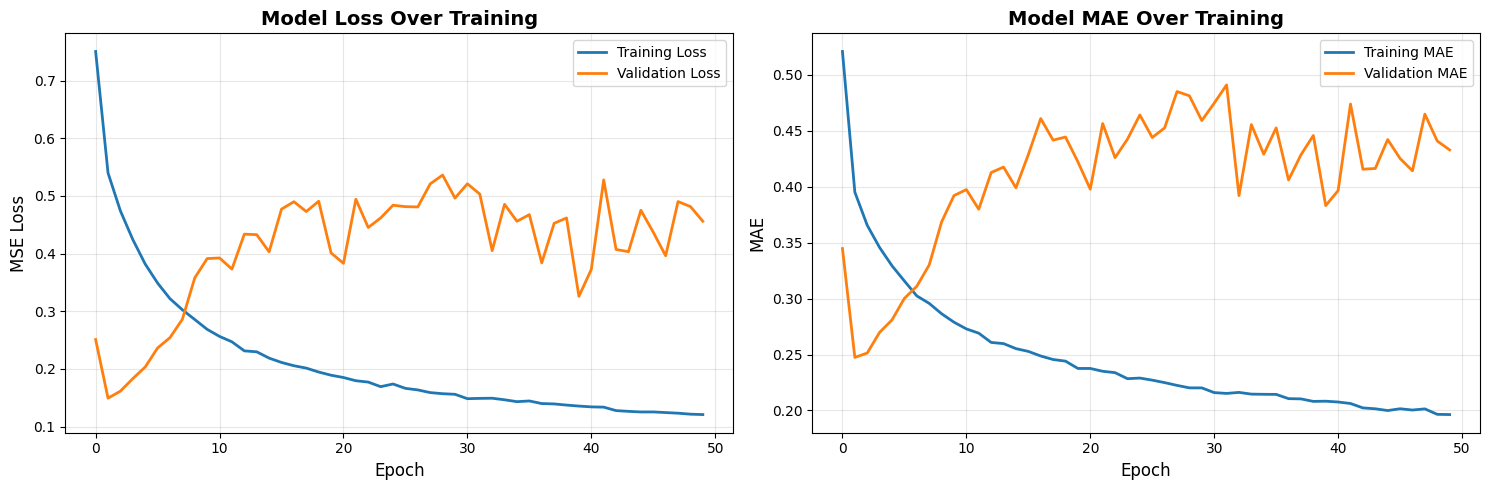

In [ ]:
import matplotlib.pyplot as plt

# Plot 1: Training History (Loss and MAE over epochs)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('MSE Loss', fontsize=12)
ax1.set_title('Model Loss Over Training', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# MAE plot
ax2.plot(history.history['mae'], label='Training MAE', linewidth=2)
ax2.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('MAE', fontsize=12)
ax2.set_title('Model MAE Over Training', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


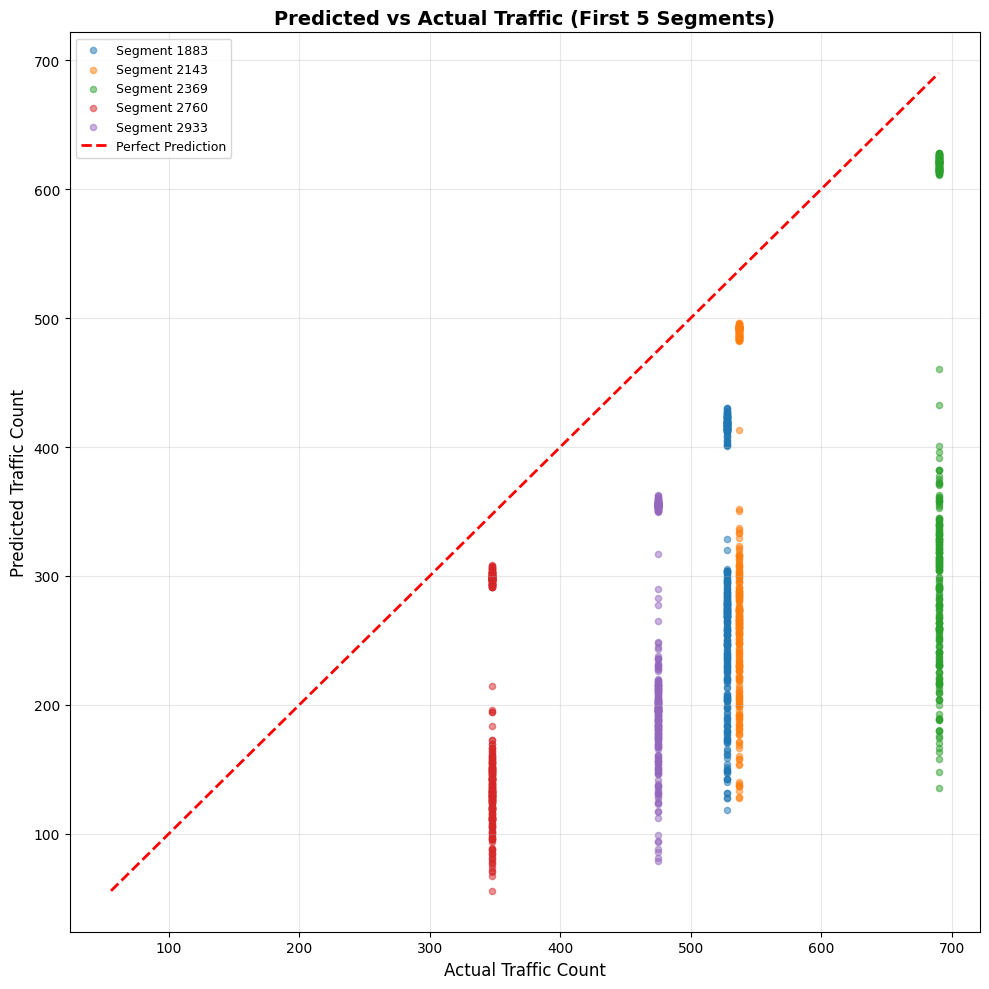

In [ ]:
# Plot 2: Predicted vs Actual scatter plot (for a subset of segments)
# Select first 5 segments to avoid overcrowding
n_segments_to_plot = 5
colors = plt.cm.tab10(range(n_segments_to_plot))

fig, ax = plt.subplots(figsize=(10, 10))

for seg_idx in range(n_segments_to_plot):
    segment_name = df_pivot.columns[seg_idx]
    ax.scatter(
        y_test[:, seg_idx],
        y_pred[:, seg_idx],
        alpha=0.5,
        s=20,
        color=colors[seg_idx],
        label=f'Segment {segment_name}'
    )

# Add perfect prediction line
max_val = max(y_test[:, :n_segments_to_plot].max(), y_pred[:, :n_segments_to_plot].max())
min_val = min(y_test[:, :n_segments_to_plot].min(), y_pred[:, :n_segments_to_plot].min())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual Traffic Count', fontsize=12)
ax.set_ylabel('Predicted Traffic Count', fontsize=12)
ax.set_title('Predicted vs Actual Traffic (First 5 Segments)', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Check R² per segment
segment_r2_scores = []
for seg_idx in range(n_segments):
    seg_r2 = r2_score(y_test[:, seg_idx], y_pred[:, seg_idx])
    segment_r2_scores.append({
        'segment': df_pivot.columns[seg_idx],
        'r2': seg_r2,
        'mean_actual': y_test[:, seg_idx].mean(),
        'std_actual': y_test[:, seg_idx].std()
    })

r2_df = pd.DataFrame(segment_r2_scores).sort_values('r2', ascending=False)

print("\nTop 10 performing segments:")
print(r2_df.head(10))

print("\nBottom 10 performing segments:")
print(r2_df.tail(10))


Top 10 performing segments:
     segment        r2  mean_actual  std_actual
637   136481  0.239582    53.233456   62.991070
131    27139  0.214321   300.368866  252.474152
981   257463  0.127521  1362.425903  419.190552
722   146888  0.089021   142.329041   36.189423
330    41720  0.081868   381.750610   94.382477
720   146886  0.080840   118.506737   25.974888
710   146496  0.074769   155.014709   31.151785
407    67560  0.048878   488.458954  178.998093
463    75313  0.045416   150.750610   42.508385
797   154501  0.044768   150.012253   37.857136

Bottom 10 performing segments:
     segment          r2  mean_actual  std_actual
758   150549   -7.654245   667.071716  149.735245
237    33645   -7.774547   662.733459  133.954269
393    62211   -9.535569   730.784912  128.133224
210    32364  -10.988720   679.973633  181.190842
890   164329  -13.800515   270.557587   84.010590
280    36036  -14.625095   388.491425   68.198914
266    34654  -18.690546   743.169128  134.961700
725   14734

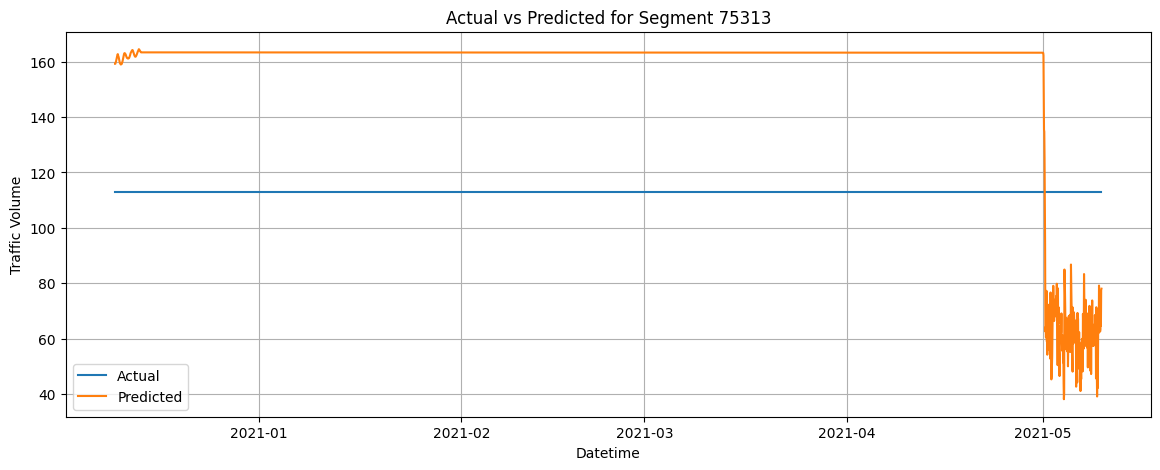

In [ ]:

def plot_segment_predictions(segment_id, y_test, y_pred, df_pivot, test_mask, datetimes):
    """
    Plot actual vs predicted values for a single roadway segment.
    """

    if segment_id not in df_pivot.columns:
        print(f"Segment {segment_id} not found in dataset.")
        return

    # Get index of the segment in the y-pred/y-test arrays
    seg_index = list(df_pivot.columns).index(segment_id)

    # Extract true and predicted for that segment
    actual = y_test[:, seg_index]
    predicted = y_pred[:, seg_index]

    # Extract datetimes for test set only
    test_datetimes = datetimes[test_mask]

    # Plot
    plt.figure(figsize=(14, 5))
    plt.plot(test_datetimes, actual, label="Actual")
    plt.plot(test_datetimes, predicted, label="Predicted")
    plt.xlabel("Datetime")
    plt.ylabel("Traffic Volume")
    plt.title(f"Actual vs Predicted for Segment {segment_id}")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_segment_predictions(75313, y_test, y_pred, df_pivot, test_mask, datetimes)




In [ ]:
# Check R² per segment to see which ones are dragging performance down
from sklearn.metrics import r2_score

segment_r2_scores = []
for seg_idx in range(n_segments):
    try:
        seg_r2 = r2_score(y_test[:, seg_idx], y_pred[:, seg_idx])
        segment_r2_scores.append({
            'segment': df_pivot.columns[seg_idx],
            'r2': seg_r2,
            'mean_actual': y_test[:, seg_idx].mean(),
            'std_actual': y_test[:, seg_idx].std()
        })
    except:
        pass

r2_df = pd.DataFrame(segment_r2_scores).sort_values('r2')

print("WORST performing segments:")
print(r2_df.head(10))

print("\nBEST performing segments:")
print(r2_df.tail(10))

# Check if low-variance segments are the problem
print("\nSegments with low actual variance (< 10):")
print(r2_df[r2_df['std_actual'] < 10])

WORST performing segments:
      segment         r2  mean_actual  std_actual
459     39756 -23.330791     0.192689    1.508355
181     26197  -9.854415    35.562008    4.399371
15       2930  -7.610314    29.656645    6.268612
1802  9001846  -2.869165   208.269211    2.176046
1701   194358  -2.799848     0.513837    4.022282
331     32780  -2.733376   841.715393    3.916882
75      17457  -1.148150     0.433550    3.393800
1280   144258  -0.707995  2071.182129   22.196669
178     26075  -0.510844     1.686027   13.198111
955     96661  -0.495420   316.102509   33.412289

BEST performing segments:
      segment        r2  mean_actual   std_actual
1691   193538  0.992381   938.632019   211.511642
1258   142839  0.992523  1765.402466   407.355713
1721   227764  0.992530  1857.557251   559.678955
695     68340  0.992592  2498.849365   526.603088
308     32087  0.992661   378.408264    95.310799
1171   136625  0.992709  3445.074707   925.689819
1737   240867  0.992745  2070.911621   632.794

In [ ]:
# Let's see what's actually in the test set for this segment
segment_idx = list(df_pivot.columns).index(1883)  # Find index of segment 1883

# Get the actual datetimes for test predictions
test_datetimes = datetimes[test_mask].reset_index(drop=True)

print(f"Test set date range: {test_datetimes.min()} to {test_datetimes.max()}")
print(f"Number of test samples: {len(test_datetimes)}")
print(f"\nFirst 10 test datetimes:")
print(test_datetimes.head(10))
print(f"\nLast 10 test datetimes:")
print(test_datetimes.tail(10))

Test set date range: 2012-01-09 01:00:00 to 2021-05-07 23:00:00
Number of test samples: 2927

First 10 test datetimes:
0   2012-01-09 01:00:00
1   2012-01-09 02:00:00
2   2012-01-09 03:00:00
3   2012-01-09 04:00:00
4   2012-01-09 05:00:00
5   2012-01-09 06:00:00
6   2012-01-09 07:00:00
7   2012-01-09 08:00:00
8   2012-01-09 09:00:00
9   2012-01-09 10:00:00
dtype: datetime64[ns]

Last 10 test datetimes:
2917   2021-05-07 14:00:00
2918   2021-05-07 15:00:00
2919   2021-05-07 16:00:00
2920   2021-05-07 17:00:00
2921   2021-05-07 18:00:00
2922   2021-05-07 19:00:00
2923   2021-05-07 20:00:00
2924   2021-05-07 21:00:00
2925   2021-05-07 22:00:00
2926   2021-05-07 23:00:00
dtype: datetime64[ns]


In [ ]:
# Check if those zeros are real or data issues
segment_actual = y_test[:, segment_idx]
near_zero_count = (segment_actual < 50).sum()
print(f"\nSegment 1883 statistics:")
print(f"Mean: {segment_actual.mean():.1f}")
print(f"Min: {segment_actual.min():.1f}")
print(f"Max: {segment_actual.max():.1f}")
print(f"Values < 50: {near_zero_count} out of {len(segment_actual)}")


Segment 1883 statistics:
Mean: 582.6
Min: 8.0
Max: 737.0
Values < 50: 6 out of 2927


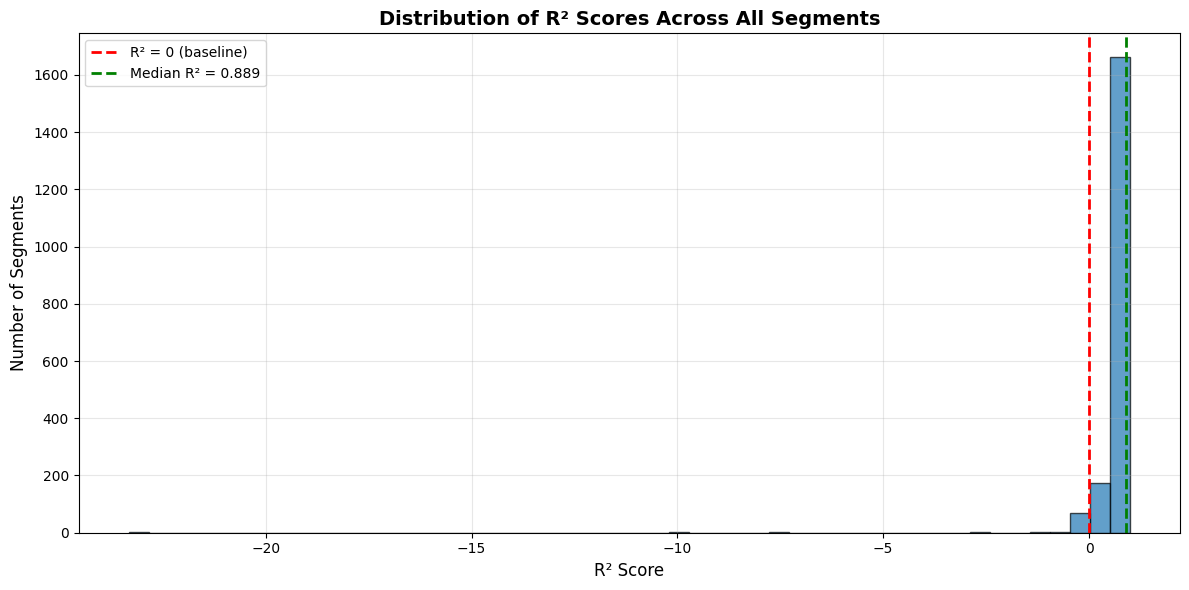


R² Statistics across segments:
Mean: 0.755
Median: 0.889
Min: -23.331
Max: 0.993


In [ ]:
# Plot R² distribution across all segments
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(r2_df['r2'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='r', linestyle='--', linewidth=2, label='R² = 0 (baseline)')
ax.axvline(x=r2_df['r2'].median(), color='g', linestyle='--', linewidth=2,
           label=f'Median R² = {r2_df["r2"].median():.3f}')
ax.set_xlabel('R² Score', fontsize=12)
ax.set_ylabel('Number of Segments', fontsize=12)
ax.set_title('Distribution of R² Scores Across All Segments', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nR² Statistics across segments:")
print(f"Mean: {r2_df['r2'].mean():.3f}")
print(f"Median: {r2_df['r2'].median():.3f}")
print(f"Min: {r2_df['r2'].min():.3f}")
print(f"Max: {r2_df['r2'].max():.3f}")

In [ ]:
# Plot 4: Error distribution histogram
errors = y_pred - y_test
errors_flat = errors.flatten()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of errors
ax1.hist(errors_flat, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
ax1.set_xlabel('Prediction Error', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Box plot of absolute errors by segment (first 10 segments)
n_seg_boxplot = min(10, n_segments)
abs_errors_by_segment = [np.abs(errors[:, i]) for i in range(n_seg_boxplot)]
segment_labels = [str(df_pivot.columns[i])[:15] for i in range(n_seg_boxplot)]

ax2.boxplot(abs_errors_by_segment, labels=segment_labels)
ax2.set_xlabel('Segment ID', fontsize=12)
ax2.set_ylabel('Absolute Error', fontsize=12)
ax2.set_title('Absolute Error Distribution by Segment (First 10)', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Plot 5: Performance metrics summary bar chart
from sklearn.metrics import r2_score

# Calculate metrics per segment
segment_metrics = []
for seg_idx in range(min(10, n_segments)):
    seg_mse = mean_squared_error(y_test[:, seg_idx], y_pred[:, seg_idx])
    seg_mae = mean_absolute_error(y_test[:, seg_idx], y_pred[:, seg_idx])
    seg_r2 = r2_score(y_test[:, seg_idx], y_pred[:, seg_idx])
    segment_metrics.append({
        'segment': str(df_pivot.columns[seg_idx])[:15],
        'MSE': seg_mse,
        'MAE': seg_mae,
        'R²': seg_r2
    })

metrics_df = pd.DataFrame(segment_metrics)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# MSE by segment
axes[0].bar(metrics_df['segment'], metrics_df['MSE'], color='coral', edgecolor='black')
axes[0].set_ylabel('MSE', fontsize=11)
axes[0].set_title('Mean Squared Error by Segment', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# MAE by segment
axes[1].bar(metrics_df['segment'], metrics_df['MAE'], color='skyblue', edgecolor='black')
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].set_title('Mean Absolute Error by Segment', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# R² by segment
axes[2].bar(metrics_df['segment'], metrics_df['R²'], color='lightgreen', edgecolor='black')
axes[2].set_ylabel('R² Score', fontsize=11)
axes[2].set_xlabel('Segment ID', fontsize=11)
axes[2].set_title('R² Score by Segment', fontsize=13, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Plot 6: Overall metrics summary
overall_r2 = r2_score(y_test.flatten(), y_pred.flatten())

fig, ax = plt.subplots(figsize=(8, 6))

metrics_names = ['MSE', 'MAE', 'R² Score']
metrics_values = [mse, mae, overall_r2]
colors_bar = ['coral', 'skyblue', 'lightgreen']

bars = ax.bar(metrics_names, metrics_values, color=colors_bar, edgecolor='black', linewidth=1.5)

# Add value labels on top of bars
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Metric Value', fontsize=12)
ax.set_title('Overall Model Performance Metrics', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"OVERALL MODEL PERFORMANCE SUMMARY")
print(f"{'='*50}")
print(f"Mean Squared Error (MSE):  {mse:,.2f}")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"R² Score:                  {overall_r2:.4f}")
print(f"{'='*50}\n")

In [ ]:
# Overview plots: distribution and sample time series
import matplotlib.pyplot as plt
import seaborn as sns

# Basic info
n_hours, n_segments = df_pivot.shape
print(f"Dataset: {n_hours} hourly rows, {n_segments} segments")

# Total traffic per segment (descending)
segment_sums = df_pivot.sum()
plt.figure(figsize=(12,5))
segment_sums.sort_values(ascending=False).head(30).plot(kind='bar')
plt.title('Total traffic per segment (top 30)')
plt.ylabel('Total traffic')
plt.tight_layout()
plt.show()

# Time series for top 5 busiest segments
top_segments = segment_sums.sort_values(ascending=False).head(5).index.tolist()
plt.figure(figsize=(14,5))
for seg in top_segments:
    plt.plot(df_pivot.index, df_pivot[seg], label=str(seg))
plt.legend()
plt.title('Hourly traffic for top 5 segments')
plt.xlabel('Datetime')
plt.ylabel('Traffic Count')
plt.tight_layout()
plt.show()

# Plot daily aggregate (optional) to see seasonality
daily = df_pivot.resample('D').sum()
plt.figure(figsize=(12,4))
plt.plot(daily.index, daily.sum(axis=1))
plt.title('Total daily traffic across all segments')
plt.ylabel('Daily total traffic')
plt.tight_layout()
plt.show()

In [ ]:
# Correlation heatmap among top segments
import matplotlib.pyplot as plt
import seaborn as sns

# Limit to top N segments (by total traffic) to keep heatmap readable
top_n = min(30, df_pivot.shape[1])
top_idx = df_pivot.sum().sort_values(ascending=False).head(top_n).index
corr = df_pivot[top_idx].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0, xticklabels=True, yticklabels=True)
plt.title(f'Correlation heatmap for top {top_n} segments')
plt.tight_layout()
plt.show()

In [ ]:
# Training history and example predictions vs truth
import matplotlib.pyplot as plt
import pandas as pd

# Plot training history if available
if 'history' in globals() and hasattr(history, 'history'):
    h = pd.DataFrame(history.history)
    plt.figure(figsize=(10,4))
    plt.plot(h['loss'], label='train_loss')
    if 'val_loss' in h.columns:
        plt.plot(h['val_loss'], label='val_loss')
    plt.title('Training loss')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No `history` object found (train the model first)')

# Show example predictions vs truth for a few segments if available
if 'y_pred' in globals() and 'y_test' in globals():
    sample_idx = 0
    pred_series = pd.Series(y_pred[sample_idx, :], index=df_pivot.columns)
    true_series = pd.Series(y_test[sample_idx, :], index=df_pivot.columns)
    compare = pd.DataFrame({'pred': pred_series, 'true': true_series})
    # show top 10 segments by true value for this sample
    top10 = compare['true'].abs().sort_values(ascending=False).head(10).index
    display(compare.loc[top10])
    # bar plot comparison
    compare.loc[top10].plot(kind='bar', figsize=(10,4))
    plt.title('Prediction vs Truth for top 10 segments (sample 0)')
    plt.tight_layout()
    plt.show()
else:
    print('No predictions found (run the model prediction step first)')

In [ ]:
# Temporal error analysis: MAE by hour-of-day and day-of-week
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Map test predictions back to their datetime indices
# The test set corresponds to datetimes starting from split + window
test_start_idx = split + window
test_datetimes = df_pivot.index[test_start_idx : test_start_idx + len(y_test)]

# Extract hour-of-day and day-of-week
hour_of_day = test_datetimes.hour
day_of_week = test_datetimes.day_name()
day_num = test_datetimes.dayofweek  # 0=Mon, 6=Sun

# Compute per-sample MAE (average absolute error across all segments for that sample)
per_sample_mae = np.mean(np.abs(y_pred - y_test), axis=1)

# Create a results dataframe
results = pd.DataFrame({
    'datetime': test_datetimes,
    'hour_of_day': hour_of_day,
    'day_of_week': day_of_week,
    'day_num': day_num,
    'mae': per_sample_mae
})

print('Temporal Error Analysis')
print('='*60)
print(f"Total test samples: {len(results)}")
print(f"Overall MAE (averaged across segments): {results['mae'].mean():.2f}")
print()

# Error by hour of day
hour_mae = results.groupby('hour_of_day')['mae'].agg(['mean', 'std', 'count'])
print('MAE by Hour of Day (0=midnight, 12=noon, 23=11pm):')
print(hour_mae)
print()

# Error by day of week
day_mae = results.groupby(['day_num', 'day_of_week'])['mae'].agg(['mean', 'std', 'count'])
print('MAE by Day of Week:')
print(day_mae)
print()

# Visualization 1: MAE by hour of day
plt.figure(figsize=(14, 4))
hour_mae['mean'].plot(kind='bar', color='steelblue', alpha=0.7, edgecolor='black')
plt.fill_between(range(len(hour_mae)),
                  hour_mae['mean'] - hour_mae['std'],
                  hour_mae['mean'] + hour_mae['std'],
                  alpha=0.2, color='steelblue')
plt.title('Mean Absolute Error (MAE) by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('MAE (avg cars per segment)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Visualization 2: MAE by day of week
plt.figure(figsize=(10, 4))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_mae_sorted = day_mae.loc[[i for i in range(7) if i in day_mae.index]]
day_mae_sorted.index = [day_order[i] for i in day_mae_sorted.index.get_level_values(0)]
day_mae_sorted['mean'].plot(kind='bar', color='coral', alpha=0.7, edgecolor='black')
plt.fill_between(range(len(day_mae_sorted)),
                  day_mae_sorted['mean'] - day_mae_sorted['std'],
                  day_mae_sorted['mean'] + day_mae_sorted['std'],
                  alpha=0.2, color='coral')
plt.title('Mean Absolute Error (MAE) by Day of Week')
plt.ylabel('MAE (avg cars per segment)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Visualization 3: Heatmap of MAE by hour and day
heatmap_data = results.pivot_table(values='mae', index='day_of_week', columns='hour_of_day', aggfunc='mean')
# Reorder rows by day of week
day_order_full = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex([d for d in day_order_full if d in heatmap_data.index])

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='RdYlGn_r', annot=False, cbar_kws={'label': 'MAE'})
plt.title('MAE Heatmap: Hour of Day vs Day of Week\n(Red = higher error, Green = lower error)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

# Find worst and best performing times
worst_hour = hour_mae['mean'].idxmax()
best_hour = hour_mae['mean'].idxmin()
worst_day_idx = day_mae['mean'].idxmax()
best_day_idx = day_mae['mean'].idxmin()

print('Summary:')
print(f"Highest error hour: Hour {worst_hour} (MAE={hour_mae['mean'].max():.2f})")
print(f"Lowest error hour:  Hour {best_hour} (MAE={hour_mae['mean'].min():.2f})")
print(f"Highest error day:  {worst_day_idx[1]} (MAE={day_mae['mean'].max():.2f})")
print(f"Lowest error day:   {best_day_idx[1]} (MAE={day_mae['mean'].min():.2f})")